In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("Compaction_notebook.ipynb")

# Geotechnical and Geoenvironmental Engineering: Soil Compaction and the Proctor Test

> **Alex Frantzis** <br> Cool Student >:3, UC Berkeley

[![License](https://img.shields.io/badge/license-CC%20BY--NC--ND%204.0-blue)](https://creativecommons.org/licenses/by-nc-nd/4.0/)
***

In this assignment, you will follow the Proctor compaction test procedure and develop code that automates the processing of laboratory data to identify the optimum moisture content and maximum dry density of a soil sample.

In [2]:
# Please run this cell, and do not modify the contents

import hashlib
def get_hash(num):
    """Helper function for assessing correctness"""
    return hashlib.md5(str(num).encode()).hexdigest()
    
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Soil Compaction
Soil compaction is the mechanical process of increasing soil density by reducing the volume of air voids within a soil mass. In geotechnical engineering, proper compaction is essential because it improves:

- Shear strength  
- Bearing capacity  
- Stiffness  
- Resistance to settlement  

Compaction is typically achieved using rollers, rammers, or vibratory equipment in the field. The effectiveness of compaction depends strongly on the **water content** of the soil.

At low water contents, soil particles experience high friction and cannot easily rearrange into a dense configuration. As water content increases, water acts as a lubricant, allowing particles to move into a more compact arrangement. Beyond a certain point, however, excess water begins to occupy space that could otherwise be filled by soil particles, reducing the achievable dry density.

This behavior leads to a characteristic peak in dry density known as the **optimum moisture content (OMC)**.

---

## The Proctor Compaction Test
The Proctor test is a laboratory procedure used to determine the relationship between **dry density** and **water content** for a given soil.

In the test:
1. Soil is mixed with a known amount of water
2. The soil is compacted into a mold using a standardized hammer
3. The bulk density and water content are measured
4. The dry density is calculated
5. The process is repeated for several water contents

The results are plotted as a **compaction curve**, with dry density on the vertical axis and water content on the horizontal axis.

The peak of this curve defines:
- **Maximum Dry Density (MDD)**
- **Optimum Water Content (OMC)**

Standardized versions of this test are defined by organizations (e.g., ASTM D698 and ASTM D1557).


## Question 1: Compaction Curve Plotting

Write a function named `fitCompactionCurve()`, that fits a polynomial curve to the **dry density versus water content** for Proctor test data.

### Input Arguments
This function has the following input arguments:

- `waterContent`, the water contents of the soil samples (in percent). This may be an array-like data type such as a list, NumPy array, or pandas Series.

- `dryDensity`, the corresponding dry densities of the soil samples (in kN/m³).

- `fitDegree`, the degree of the polynomial used to fit the compaction curve (typically 2).

### Output
- `curve`, a polynomial function fitted to the data.
---

We have provided sample code through a function called `createFigure()`, that creates a figure using the `fitCompactionCurve()` function that you create. Use it to visualize and verify your line fitting. An example curve fitted to a two degree polynomial is shown below.
<center><img src="resources/Curve_Example.png" width='650'/></center>

---
    
For testing purposes, please use np.polyfit in order to fit your polynomials. If you don't, your code may not pass the autograder. Documentation is linked below.
- np.polyfit (getting polynmial coefficients): https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html
- np.poly1d (turning coefficients into usable function): nhttps://numpy.org/doc/stable/reference/generated/numpy.poly1d.html

In [3]:
def fitCompactionCurve(waterContent, dryDensity, fitDegree):
    # Convert to NumPy arrays
    waterContent = np.array(waterContent)
    dryDensity = np.array(dryDensity)
    
    # Get polynomial coefficients using np.polyfit
    coeffs = np.polyfit(waterContent, dryDensity, fitDegree) # SOLUTION

    # Create function using np.poly1d
    curve = np.poly1d(coeffs) # SOLTION

    return curve

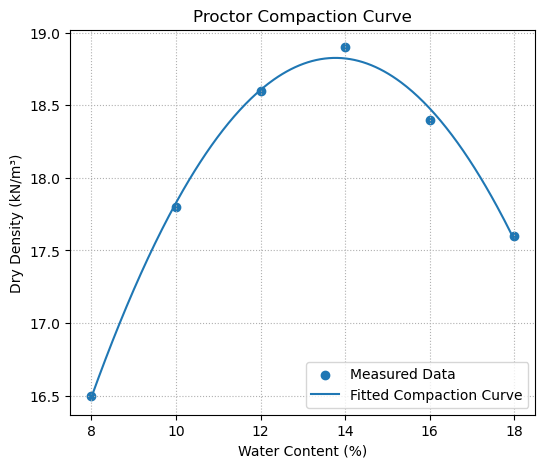

In [4]:
# Define Proctor test data
waterContent = [8, 10, 12, 14, 16, 18]          # percent
dryDensity   = [16.5, 17.8, 18.6, 18.9, 18.4, 17.6]  # kN/m^3
fitDegree = 2 # Degree of polynomial to be fitted.

def createFigure(waterContent, dryDensity, fitDegree):

    # Get the fitted curve using fitCompactionCurve
    poly_fn = fitCompactionCurve(waterContent, dryDensity, fitDegree)
    
    # Plot
    w_smooth = np.linspace(min(waterContent), max(waterContent), 300)
    gamma_smooth = poly_fn(w_smooth)
    
    fig_1 = plt.figure(figsize=(6, 5))  # Do not change this line

    plt.scatter(waterContent, dryDensity, label="Measured Data")  # SOLUTION
    plt.plot(w_smooth, gamma_smooth, label="Fitted Compaction Curve")  # SOLUTION

    plt.xlabel("Water Content (%)")  # SOLUTION
    plt.ylabel("Dry Density (kN/m³)")  # SOLUTION
    plt.title("Proctor Compaction Curve")  # SOLUTION
    plt.legend()
    plt.grid(True, linestyle=":", linewidth=0.8)

    return fig_1


fig = createFigure(waterContent, dryDensity, fitDegree)


In [5]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Your curve is well off the given solution
success_message: Curve is close to given solution :D
""" # END TEST CONFIG

# Define Proctor test data
waterContent = [8, 10, 12, 14, 16, 18]          # percent
dryDensity   = [16.5, 17.8, 18.6, 18.9, 18.4, 17.6]  # kN/m^3
fitDegree = 2

poly_fn = fitCompactionCurve(waterContent, dryDensity, fitDegree)
assert get_hash(np.round(poly_fn(9), 1)) == '1b7f864ac7a422c1a24c720d543e7e0f'
assert get_hash(np.round(poly_fn(10), 1)) == '1383c2b19889c144c1c67203d8f7d201'
assert get_hash(np.round(poly_fn(11), 1)) == '2915286d7ad2c7a98aa7d4bb99a6af5c'
assert get_hash(np.round(poly_fn(12), 1)) == 'f956db20c1a24280c453c61bbb1ec9f6'
assert get_hash(np.round(poly_fn(13.4), 1)) == '4652e04e446dd7e02c704d4189292a1c'
assert get_hash(np.round(poly_fn(17), 1)) == 'd2de50745be374846c0b044a1d67d7a1'

## Degree of Saturation Lines

Degree of saturation lines show the relationship between **dry density** and **water content** at fixed saturation levels. The degree of saturation is the ratio of water volume to void volume:

$$
S = \frac{V_w}{V_v}
$$

where:
- $V_w$ is the volume of water  
- $V_v$ is the volume of voids  

The dry density corresponding to a given degree of saturation is:

$$
\gamma_d = \frac{G_s \, \gamma_w}{1 + \frac{w \, G_s}{S}}
$$

where:
- $\gamma_d$ is dry density  
- $G_s$ is the specific gravity of solids  
- $\gamma_w$ is the unit weight of water  
- $w$ is water content (decimal)  
- $S$ is degree of saturation (decimal)  

The **100% saturation line** ($S = 1.0$) is called the **Zero Air Voids (ZAV) line** and represents the maximum theoretical dry density. Real compaction data should always lie below this line.  

Typical compacted soils at optimum water content have $S$ between 0.8 and 0.95.



## Question 2: Degree of Saturation Lines

Write a function named `getSaturationDensity()`, that calculates the theoretical dry density corresponding to different degrees of saturation and water content. Use the formula derived above.

### Input Arguments
This function has the following input arguments:

- `waterContent`, the water contents of the soil samples (in percent). This may be an array-like data type such as a list, NumPy array, or pandas Series.

- `specificGravity`, the specific gravity of the solids in the soil. 

- `saturation`, the saturation of the soil.

### Output
- `dryDensity`, the theoretical dry density of the sample using the equation given above.

In [8]:
def getSaturationDensity(waterContent, specificGravity, saturation, gamma_w = 9.81):
    # Convert waterContent to np.array
    
    # Convert percentage to decimal
    waterContent = waterContent / 100 # SOLUTION

    dryDensity = spectificGravity *  gamma_w/ (1 + waterContent * specificGravity/saturation) # SOLUTION
    return dryDensity

## Question 3: Data Observations

You will now use the functions that you have created to graph things out and make decisions about the quality of you in situ soil.

Suppose you are on site and given the following list of soil samples. 

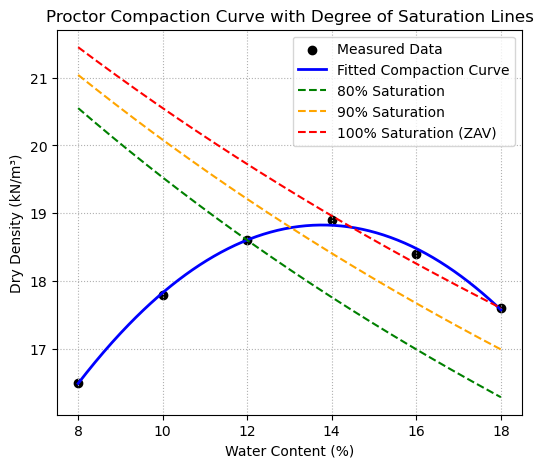

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Define Proctor test data
waterContent = [8, 10, 12, 14, 16, 18]          # percent
dryDensity   = [16.5, 17.8, 18.6, 18.9, 18.4, 17.6]  # kN/m^3
fitDegree = 2

def createFigure(waterContent, dryDensity, fitDegree):

    # Convert to NumPy arrays
    waterContent = np.array(waterContent)
    dryDensity = np.array(dryDensity)

    # Get the fitted curve using fitCompactionCurve
    poly_fn = fitCompactionCurve(waterContent, dryDensity, fitDegree)
    
    # Smooth range for plotting
    w_smooth = np.linspace(min(waterContent), max(waterContent), 300)
    gamma_smooth = poly_fn(w_smooth)

    # -----------------------------
    # Degree of Saturation Lines
    # -----------------------------
    Gs = 2.65          # specific gravity of solids
    gamma_w = 9.81     # kN/m^3
    w_decimal = w_smooth / 100

    S_values = [0.8, 0.9, 1.0]
    saturation_curves = {}

    for S in S_values:
        gamma_d = getSaturationDensity(waterContent, specificGravity, saturation)
        saturation_curves[S] = gamma_d

    # -----------------------------
    # Plot
    # -----------------------------
    fig_1 = plt.figure(figsize=(6, 5))  # Do not change this line

    plt.scatter(
        waterContent, dryDensity,
        color="black", label="Measured Data"
    )

    plt.plot(
        w_smooth, gamma_smooth,
        color="blue", linewidth=2,
        label="Fitted Compaction Curve"
    )

    plt.plot(
        w_smooth, saturation_curves[0.8],
        linestyle="--", color="green",
        label="80% Saturation"
    )

    plt.plot(
        w_smooth, saturation_curves[0.9],
        linestyle="--", color="orange",
        label="90% Saturation"
    )

    plt.plot(
        w_smooth, saturation_curves[1.0],
        linestyle="--", color="red",
        label="100% Saturation (ZAV)"
    )

    plt.xlabel("Water Content (%)")
    plt.ylabel("Dry Density (kN/m³)")
    plt.title("Proctor Compaction Curve with Degree of Saturation Lines")
    plt.legend()
    plt.grid(True, linestyle=":", linewidth=0.8)

    return fig_1


fig = createFigure(waterContent, dryDensity, fitDegree)
